In [1]:
# ====================================================================
# 0. imports & reproducibility
# ====================================================================
import pandas as pd, numpy as np, tensorflow as tf, matplotlib.pyplot as plt
from tcn import TCN
from sklearn.metrics import mean_squared_error, r2_score
import pandas as pd
from pathlib import Path

rng = np.random.default_rng(42)
tf.keras.utils.set_random_seed(42)
tf.debugging.enable_check_numerics()          # crash early on NaN/Inf

INFO:tensorflow:Enabled check-numerics callback in thread MainThread


In [2]:
# ------------------------------------------------------------------
# files you want to merge  (add as many as you like)
# ------------------------------------------------------------------
FILES = [
    "previous_dv0_withoutstraw_sipCAdded.xlsx", 
    "dv0_withoutstraw_sipCAdded.xlsx",
                       # ← put your second file name here
    # "third_file.xlsx",
]

In [3]:
# ------------------------------------------------------------------
# read & re-index
# ------------------------------------------------------------------
dfs          = []
next_offset  = 0          # keeps track of the next free Participant_ID

for fp in FILES:
    fp = Path(fp)
    df = pd.read_excel(fp)

    # current file's min/max before shifting (optional print for sanity)
    old_min, old_max = df["Participant_ID"].min(), df["Participant_ID"].max()
    print(f"{fp.name}: original IDs {old_min} … {old_max}")

    # shift IDs so they don't collide with previous files
    df["Participant_ID"] += next_offset

    # update next_offset for the *next* file
    next_offset = df["Participant_ID"].max() + 1

    # done
    dfs.append(df)
    print(f"   shifted to {df['Participant_ID'].min()} … {df['Participant_ID'].max()}")


previous_dv0_withoutstraw_sipCAdded.xlsx: original IDs 6 … 62
   shifted to 6 … 62
dv0_withoutstraw_sipCAdded.xlsx: original IDs 1 … 14
   shifted to 64 … 77


In [4]:
# ------------------------------------------------------------------
# combined DataFrame
# ------------------------------------------------------------------
df_all = pd.concat(dfs, ignore_index=True)
print("\nMerged dataframe shape:", df_all.shape)
print("Global Participant_ID range:", df_all["Participant_ID"].min(),
      "…", df_all["Participant_ID"].max())


Merged dataframe shape: (99996, 82)
Global Participant_ID range: 6 … 77


In [5]:
df_all

,Unnamed: 0,Time,Zone_0,Zone_1,Zone_2,Zone_3,Zone_4,Zone_5,Zone_6,Zone_7,...,Container_Weight,drink,temp,prev,next,sip_start,sip_end,sip_id,dV,TOTAL_SIP_TIME
0,0,1747823631000,2162,2155,3941,362,324,342,3605,2071,...,19.8,coke-r,c,0,0,False,False,0,0.0,0
1,1,1747823631200,2162,2155,3941,362,324,342,3605,2071,...,19.8,coke-r,c,0,0,False,False,0,0.0,0
2,2,1747823631400,2162,2155,3941,362,324,342,3605,2071,...,19.8,coke-r,c,0,0,False,False,0,0.0,0
3,3,1747823631600,2162,2155,3941,362,324,342,3605,2071,...,19.8,coke-r,c,0,0,False,False,0,0.0,0
4,4,1747823631800,2162,2155,3941,362,324,342,3605,2071,...,19.8,coke-r,c,0,0,False,False,0,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99991,20621,1750719007400,1647,1625,1610,1610,1592,1569,1580,1569,...,7.7,water,n,0,0,False,False,5,0.0,0
99992,20622,1750719007600,1637,1611,1592,1596,1570,1569,1575,1569,...,7.7,water,n,0,0,False,False,5,0.0,0
99993,20623,1750719007800,1607,1607,1592,1595,1568,1567,1560,1566,...,7.7,water,n,0,0,False,False,5,0.0,0
99994,20624,1750719008000,1602,1593,1586,1585,1568,1562,1560,1560,...,7.7,water,n,0,0,False,False,5,0.0,0


In [6]:
df = df_all

In [7]:
# print("Label stats  (raw, before scaling)")
# print("  min :", y.min())
# print("  #zeros :", (y == 0).sum())
# print("  any negative? ", (y < 0).any())

In [8]:

# --------------------------------------------------------------------
# user settings
# --------------------------------------------------------------------

BATCH      = 2                                   # 1 = ragged, >1 = padded


In [9]:
# ====================================================================
# 1. load data  ➜  X(list of (T,64)), y(array)   – SKIP zero-volume sips
# ====================================================================
df = df[df["Label"] == 1]                        # keep only annotated frames

feature_cols = df.columns[2:66]
seq_keys, label_col = ["Participant_ID", "sip_id"], "dV"

X, y = [], []
skip_count = 0

for _, g in df.groupby(seq_keys, sort=False):
    dV = float(g[label_col].iloc[0])
    if dV == 0.0:                                # ← drop empty sip
        skip_count += 1
        continue
    X.append(g[feature_cols].to_numpy(np.float32))   # (T,64)
    y.append(dV)

y = np.asarray(y, np.float32)
X = np.array(X, dtype=object)   # each element is still a (T,64) array
print(f"Total sips kept : {len(X)}")
print(f"Zero-volume skipped : {skip_count}")
print("Label stats  → min:", y.min(), "max:", y.max())

Total sips kept : 383
Zero-volume skipped : 2
Label stats  → min: 1.4691479 max: 160.2


In [10]:
X[:1]

array([array([[2487.,  165.,  348., ...,  364.,  330., 1817.],
              [2487.,  165.,  348., ...,  364.,  330., 1817.],
              [ 265.,  200.,  234., ...,  364.,  352., 1817.],
              ...,
              [ 304., 2267., 2300., ...,  331., 1449., 1140.],
              [ 299., 2267., 2300., ...,  352.,  352., 1151.],
              [ 295., 2280., 2300., ...,  352., 1449., 1151.]], dtype=float32)],
      dtype=object)

In [11]:
print(type(X))          # <class 'numpy.ndarray'>
print(X.shape)          # (number,)

print(type(X[0]))       # <class 'numpy.ndarray'>
print(X[0].shape)       # (rows, columns)

<class 'numpy.ndarray'>
(383,)
<class 'numpy.ndarray'>
(26, 64)


In [12]:
# ====================================================================
# 2. shuffle whole sips ➜ 80 / 20 split
# ====================================================================
idx = rng.permutation(len(X))
split1 = int(.64 * len(X))          # 64 % train
split2 = int(.80 * len(X))          # next 16 % val
X_train, y_train = X[idx[:split1]], y[idx[:split1]]
X_val,   y_val   = X[idx[split1:split2]], y[idx[split1:split2]]
X_test,  y_test  = X[idx[split2:]], y[idx[split2:]]
print(f"Train {len(X_train)} Val {len(X_val)}  Test {len(X_test)}")
# y_train_s = np.log1p(y_train)        # log1p for numerical safety
# y_val_s   = np.log1p(y_val)
# y_test_s  = np.log1p(y_test)


Train 245 Val 61  Test 77


In [13]:
# X_train


In [14]:
# y_train

In [15]:
# ====================================================================
# 3. column-wise z-score normalisation (fit on training only)
# ====================================================================
mat_train = np.vstack(X_train)          # ⬅ only TRAIN data
mean64 = mat_train.mean(0, keepdims=True)
std64  = mat_train.std(0,  keepdims=True) + 1e-8

norm = lambda seq: (seq - mean64) / std64
X_train = [norm(s) for s in X_train]
X_val   = [norm(s) for s in X_val]
X_test  = [norm(s) for s in X_test]

# # label scaling
# y_max   = y_train.max() or 1.
# y_train_s = y_train / y_max
# y_val_s   = y_val   / y_max
# y_test_s  = y_test  / y_max
y_train_s = y_train 
y_val_s   = y_val   
y_test_s  = y_test  



In [16]:
# X_train

In [17]:
# ====================================================================
# 4. tf.data pipelines
# ====================================================================
def generator(xs, ys):
    for x, y in zip(xs, ys):
        yield x, y

output_sig = (
    tf.TensorSpec((None, 64), tf.float32),
    tf.TensorSpec((),          tf.float32)
)

def make_ds(xs, ys, shuffle=True):
    ds = tf.data.Dataset.from_generator(lambda: generator(xs, ys),
                                        output_signature=output_sig)
    if shuffle:
        ds = ds.shuffle(len(xs), seed=42)
    if BATCH == 1:
        return ds.repeat().batch(1)              # ragged
    return ds.repeat().padded_batch(             # padded
        BATCH,
        padded_shapes=([None, 64], []),
        padding_values=(0.0, 0.0)
    )

train_ds = make_ds(X_train, y_train_s, shuffle=True)
val_ds   = make_ds(X_val,   y_val_s,   shuffle=False)
test_ds  = make_ds(X_test,  y_test_s,  shuffle=False)

In [18]:
train_ds

<_PaddedBatchDataset element_spec=(TensorSpec(shape=(None, None, 64), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.float32, name=None))>

In [19]:
# for batch in train_ds.take(1):
#     x_batch, y_batch = batch
#     print("x_batch shape:", x_batch.shape)
#     print("y_batch shape:", y_batch.shape)
#     print("x_batch:", x_batch.numpy())
#     print("y_batch:", y_batch.numpy())

In [20]:
# ====================================================================
# 5. model  – TCN ➜ Dense(1, softplus) keeps output ≥ 0
# ====================================================================
inp = tf.keras.Input(shape=(None, 64))
x = TCN(nb_filters=128,
        kernel_size=2,
        dilations=[1,2,4,8,16,32],   # ~64-time-step field
        dropout_rate=0.1,
        return_sequences=False)(inp)
out = tf.keras.layers.Dense(1)(x)          # ← LINEAR output
model = tf.keras.Model(inp, out)

model.compile(
    tf.keras.optimizers.Adam(1e-3),        # a bit faster
    loss="mae"                             # MAE is more robust
)
model.summary()

steps_per_epoch = len(X_train) // BATCH + (len(X_train) % BATCH > 0)
val_steps       = len(X_val)   // BATCH + (len(X_val)   % BATCH > 0)
# weights = (y_train / y_train.max()) ** 0.5  
cb = tf.keras.callbacks.EarlyStopping(
         monitor='val_loss', patience=15, restore_best_weights=True)
model.fit(
    train_ds,
    epochs=50,
    steps_per_epoch=steps_per_epoch,
    validation_data=val_ds,        # ⬅ use VALIDATION set
    validation_steps=val_steps,
    verbose=1,
    # sample_weight=weights,
    callbacks=[cb]
)

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, None, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ tcn (TCN)                       │ (None, 128)            │       386,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 386,817 (1.48 MB)

 Trainable params: 386,817 (1.48 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
123/123 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 22.9722 - val_loss: 26.7316
Epoch 2/50
123/123 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 19.9117 - val_loss: 17.9858
Epoch 3/50
123/123 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 16.5340 - val_loss: 14.4612
Epoch 4/50
123/123 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 14.5151 - val_loss: 16.3296
Epoch 5/50
123/123 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 15.0543 - val_loss: 15.8124
Epoch 6/50
123/123 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 14.0522 - val_loss: 14.9468
Epoch 7/50
123/123 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 13.9609 - val_loss: 14.0952
Epoch 8/50
123/123 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 11.6484 - val_loss: 13.3072
Epoch 9/50
123/123 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 14.5535 - val_loss: 14.6633
Epoch 10/50
123/123 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 11.6501 - val_loss: 16.1871
Epoch 11/50
123/123 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 14.1742 - val_loss: 13.7280
Epoch 12/50
123/123 ━━━━━━━━

In [21]:
# ====================================================================
# 6. inference on test set (un-scale predictions)
# ====================================================================
y_pred_s = np.array([model.predict(seq[None, ...], verbose=0)[0, 0]
                     for seq in X_test])
# inverse transform after prediction
# y_pred_s = np.expm1(y_pred_s)
# y_pred   = y_pred_s * y_max
y_pred = y_pred_s
y_mean, y_std = y_train.mean(), y_train.std()
y_train_s = (y_train - y_mean) / y_std
# ...
# y_pred = y_pred_s * y_std + y_mean       # undo scaling

In [22]:
# ====================================================================
# 7. evaluation
# ====================================================================
mse  = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2   = r2_score(y_test, y_pred)

non_zero = y_test != 0
rmspe = (np.sqrt(np.mean(((y_test[non_zero]-y_pred[non_zero]) /
                          y_test[non_zero])**2))*100
         if non_zero.any() else np.nan)

print(f"\nEvaluation on {len(y_test)} test sips")
print(f"  MSE   : {mse:.4f}")
print(f"  RMSE  : {rmse:.4f}")
print(f"  R²    : {r2:.4f}")
print(f"  RMSPE : {rmspe:.2f}%")

comparison_df = pd.DataFrame({"Actual dV": y_test, "Predicted dV": y_pred})
print("\nFirst 50 predictions:")
print(comparison_df.head(50))


Evaluation on 77 test sips
  MSE   : 266.4766
  RMSE  : 16.3241
  R²    : 0.5908
  RMSPE : 164.10%

First 50 predictions:
     Actual dV  Predicted dV
0   103.800003     83.927948
1    40.095238     21.951843
2     8.275862     21.326982
3    58.765915     45.936409
4    11.655240     24.284336
5     9.809524     54.812729
6    11.111111     18.951153
7    12.536729     23.568581
8    76.190475     52.548851
9    25.465231     27.311264
10   15.513834     33.839436
11    9.162561     13.657990
12   58.000000     64.743881
13   20.470127     23.950022
14   13.712047     18.504742
15   10.476191     24.926165
16   41.523811     34.885990
17   25.799999     24.033403
18   35.200001     33.031979
19   16.380953     27.404263
20  100.000000     66.209747
21   16.400000     29.143965
22    6.660137     24.325573
23   57.142857     36.868099
24   12.996032     59.511154
25   85.699997     72.029808
26   79.365082     71.847061
27   60.000000     61.348343
28   27.182539     27.558605
29   24

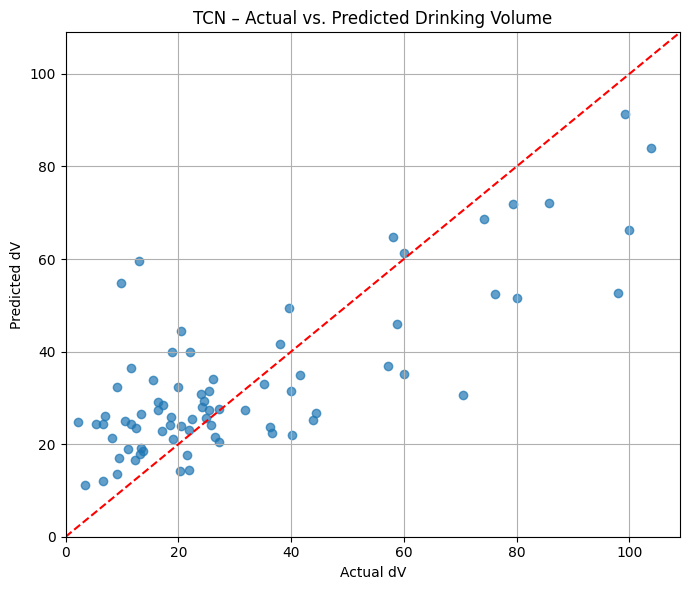

In [23]:
# ====================================================================
# 8. scatter plot
# ====================================================================
plt.figure(figsize=(7, 6))
plt.scatter(y_test, y_pred, alpha=0.7)
lims = [0, max(y_test.max(), y_pred.max()) * 1.05]
plt.plot(lims, lims, "r--")
plt.xlim(lims); plt.ylim(lims)
plt.xlabel("Actual dV"); plt.ylabel("Predicted dV")
plt.title("TCN – Actual vs. Predicted Drinking Volume")
plt.grid(True); plt.tight_layout(); plt.show()

In [24]:
# print("First 5 log targets  :", y_train_s[:5])
# print("First 5 raw targets  :", y_train[:5])

# # after one epoch
# raw_pred = np.expm1(model.predict(X_val[:3])[...,0])
# print("First 3 un-scaled predictions:", raw_pred)

In [25]:
print("train  min / max (ml):", y_train.min(), y_train.max())
print("train_s min / max (log):", y_train_s.min(), y_train_s.max())

# quick expectation check:  ln(1+160) ≈ 5.08
#                           ln(1+  5) ≈ 1.79

train  min / max (ml): 1.4691479 160.2
train_s min / max (log): -1.271691 4.6831155


In [26]:
def build_and_train_model(optimizer, optimizer_name):
    inp = tf.keras.Input(shape=(None, 64))
    x = TCN(nb_filters=256,
            kernel_size=6,
            dilations=[1,2,4,8,16,32,64],
            dropout_rate=0.1,
            return_sequences=False)(inp)
    out = tf.keras.layers.Dense(1)(x)

    model = tf.keras.Model(inp, out)
    model.compile(
        optimizer=optimizer,
        loss="mae")
           

    print(f"\n🧪 Training with optimizer: {optimizer_name}")
    model.summary()

    cb = tf.keras.callbacks.EarlyStopping(
             monitor='val_loss', patience=300, restore_best_weights=True)

    history = model.fit(
        train_ds,
        epochs=500,
        steps_per_epoch=steps_per_epoch,
        validation_data=val_ds,
        validation_steps=val_steps,
        verbose=1,
        callbacks=[cb]
    )
    
    # ====================================================================
    # 6. inference on test set (un-scale predictions)
    # ====================================================================
    y_pred_s = np.array([model.predict(seq[None, ...], verbose=0)[0, 0]
                     for seq in X_test])
    # inverse transform after prediction
    # y_pred_s = np.expm1(y_pred_s)
    # y_pred   = y_pred_s * y_max
    y_pred = y_pred_s
    y_mean, y_std = y_train.mean(), y_train.std()
    y_train_s = (y_train - y_mean) / y_std
    # ...
    # y_pred = y_pred_s * y_std + y_mean       # undo scaling  
    # ====================================================================
    # 7. evaluation
    # ====================================================================
    mse  = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2   = r2_score(y_test, y_pred)

    non_zero = y_test != 0
    rmspe = (np.sqrt(np.mean(((y_test[non_zero]-y_pred[non_zero]) /
                          y_test[non_zero])**2))*100
         if non_zero.any() else np.nan)

    print(f"\nEvaluation on {len(y_test)} test sips")
    print(f"  MSE   : {mse:.4f}")
    print(f"  RMSE  : {rmse:.4f}")
    print(f"  R²    : {r2:.4f}")
    print(f"  RMSPE : {rmspe:.2f}%")

    comparison_df = pd.DataFrame({"Actual dV": y_test, "Predicted dV": y_pred})
    print("\nFirst 50 predictions:")
    print(comparison_df.head(50))
    # ====================================================================
        # 8. scatter plot
    # ====================================================================
    plt.figure(figsize=(7, 6))
    plt.scatter(y_test, y_pred, alpha=0.7)
    lims = [0, max(y_test.max(), y_pred.max()) * 1.05]
    plt.plot(lims, lims, "r--")
    plt.xlim(lims); plt.ylim(lims)
    plt.xlabel("Actual dV"); plt.ylabel("Predicted dV")
    plt.title("TCN – Actual vs. Predicted Drinking Volume")
    plt.grid(True); plt.tight_layout(); plt.show()

    return history


In [27]:
from tensorflow.keras.optimizers import SGD, Adam, RMSprop, Adagrad, Adamax, Nadam, Adadelta

optimizers_to_test = {
    "SGD": SGD(learning_rate=0.0001, momentum=0.9),
    "RMSprop": RMSprop(learning_rate=0.001),
    "Adagrad": Adagrad(learning_rate=0.01),
    "Adadelta": Adadelta(learning_rate=1.0),
    "Adam": Adam(learning_rate=0.001),
    "Adamax": Adamax(learning_rate=0.001),
    "Nadam": Nadam(learning_rate=0.001),
}



🧪 Training with optimizer: SGD


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, None, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ tcn_1 (TCN)                     │ (None, 256)            │     5,230,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,230,593 (19.95 MB)

 Trainable params: 5,230,593 (19.95 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/500
123/123 ━━━━━━━━━━━━━━━━━━━━ 7s 32ms/step - loss: 23.8869 - val_loss: 18.9548
Epoch 2/500
123/123 ━━━━━━━━━━━━━━━━━━━━ 4s 36ms/step - loss: 15.7418 - val_loss: 16.2642
Epoch 3/500
123/123 ━━━━━━━━━━━━━━━━━━━━ 5s 40ms/step - loss: 14.2088 - val_loss: 16.4820
Epoch 4/500
123/123 ━━━━━━━━━━━━━━━━━━━━ 5s 42ms/step - loss: 14.9063 - val_loss: 16.0953
Epoch 5/500
123/123 ━━━━━━━━━━━━━━━━━━━━ 5s 42ms/step - loss: 14.2246 - val_loss: 14.8655
Epoch 6/500
123/123 ━━━━━━━━━━━━━━━━━━━━ 6s 50ms/step - loss: 10.9119 - val_loss: 14.9750
Epoch 7/500
123/123 ━━━━━━━━━━━━━━━━━━━━ 5s 42ms/step - loss: 12.6076 - val_loss: 15.3371
Epoch 8/500
123/123 ━━━━━━━━━━━━━━━━━━━━ 5s 38ms/step - loss: 11.1179 - val_loss: 14.7718
Epoch 9/500
123/123 ━━━━━━━━━━━━━━━━━━━━ 5s 42ms/step - loss: 12.2804 - val_loss: 16.4498
Epoch 10/500
123/123 ━━━━━━━━━━━━━━━━━━━━ 5s 38ms/step - loss: 11.9866 - val_loss: 15.2217
Epoch 11/500
123/123 ━━━━━━━━━━━━━━━━━━━━ 5s 38ms/step - loss: 9.9712 - val_loss: 14.9007
Epoch 12/

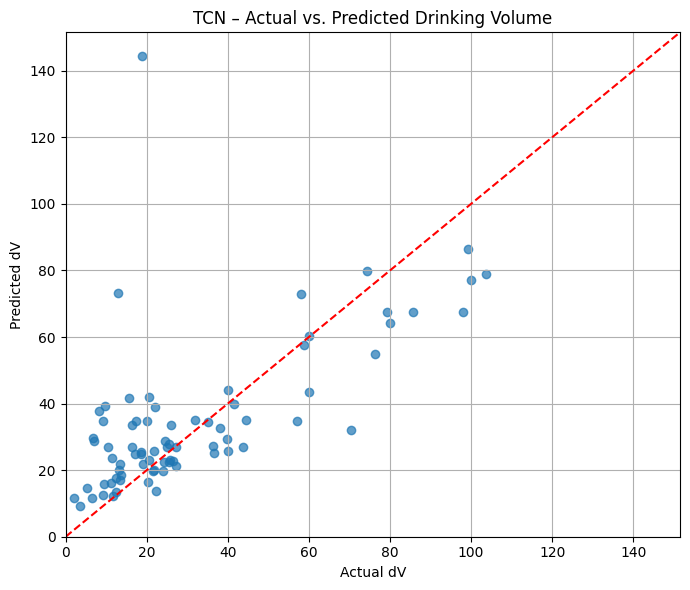


🧪 Training with optimizer: RMSprop


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, None, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ tcn_2 (TCN)                     │ (None, 256)            │     5,230,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,230,593 (19.95 MB)

 Trainable params: 5,230,593 (19.95 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/500
123/123 ━━━━━━━━━━━━━━━━━━━━ 10s 45ms/step - loss: 28.0423 - val_loss: 19.1235
Epoch 2/500
123/123 ━━━━━━━━━━━━━━━━━━━━ 6s 45ms/step - loss: 20.2978 - val_loss: 21.4755
Epoch 3/500
123/123 ━━━━━━━━━━━━━━━━━━━━ 6s 47ms/step - loss: 17.9554 - val_loss: 18.3301
Epoch 4/500
123/123 ━━━━━━━━━━━━━━━━━━━━ 6s 48ms/step - loss: 16.9026 - val_loss: 17.1269
Epoch 5/500
123/123 ━━━━━━━━━━━━━━━━━━━━ 6s 48ms/step - loss: 17.9941 - val_loss: 17.0444
Epoch 6/500
123/123 ━━━━━━━━━━━━━━━━━━━━ 6s 48ms/step - loss: 14.5595 - val_loss: 18.0668
Epoch 7/500
123/123 ━━━━━━━━━━━━━━━━━━━━ 6s 49ms/step - loss: 15.5330 - val_loss: 16.9086
Epoch 8/500
123/123 ━━━━━━━━━━━━━━━━━━━━ 6s 49ms/step - loss: 13.9113 - val_loss: 18.9929
Epoch 9/500
123/123 ━━━━━━━━━━━━━━━━━━━━ 6s 48ms/step - loss: 12.5997 - val_loss: 15.3975
Epoch 10/500
123/123 ━━━━━━━━━━━━━━━━━━━━ 6s 47ms/step - loss: 13.2018 - val_loss: 16.5665
Epoch 11/500
123/123 ━━━━━━━━━━━━━━━━━━━━ 6s 48ms/step - loss: 11.4698 - val_loss: 15.3153
Epoch 1

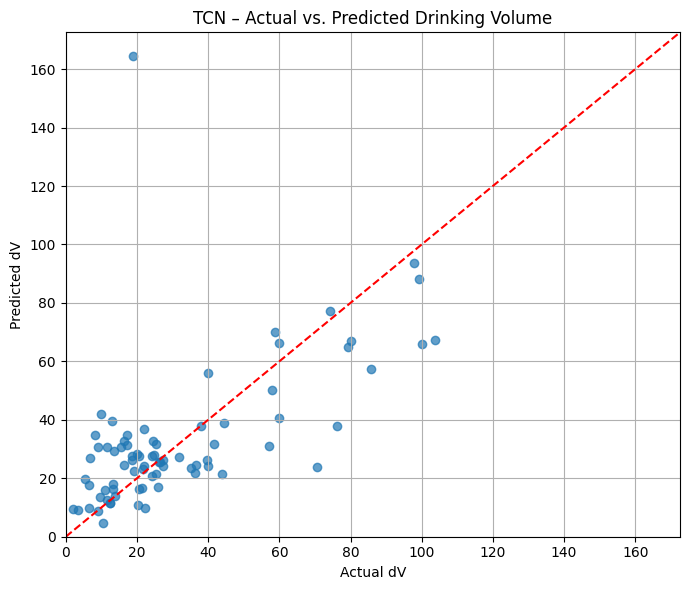


🧪 Training with optimizer: Adagrad


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, None, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ tcn_3 (TCN)                     │ (None, 256)            │     5,230,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,230,593 (19.95 MB)

 Trainable params: 5,230,593 (19.95 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/500
123/123 ━━━━━━━━━━━━━━━━━━━━ 7s 35ms/step - loss: 52.6812 - val_loss: 19.7523
Epoch 2/500
123/123 ━━━━━━━━━━━━━━━━━━━━ 5s 37ms/step - loss: 18.1277 - val_loss: 17.9842
Epoch 3/500
123/123 ━━━━━━━━━━━━━━━━━━━━ 5s 39ms/step - loss: 15.3469 - val_loss: 16.8467
Epoch 4/500
123/123 ━━━━━━━━━━━━━━━━━━━━ 5s 38ms/step - loss: 12.9693 - val_loss: 17.1589
Epoch 5/500
123/123 ━━━━━━━━━━━━━━━━━━━━ 5s 37ms/step - loss: 12.5020 - val_loss: 15.0611
Epoch 6/500
123/123 ━━━━━━━━━━━━━━━━━━━━ 4s 36ms/step - loss: 12.1147 - val_loss: 14.9103
Epoch 7/500
123/123 ━━━━━━━━━━━━━━━━━━━━ 5s 40ms/step - loss: 11.5066 - val_loss: 14.5301
Epoch 8/500
123/123 ━━━━━━━━━━━━━━━━━━━━ 5s 39ms/step - loss: 10.1423 - val_loss: 14.5184
Epoch 9/500
123/123 ━━━━━━━━━━━━━━━━━━━━ 5s 40ms/step - loss: 11.4218 - val_loss: 13.9443
Epoch 10/500
123/123 ━━━━━━━━━━━━━━━━━━━━ 5s 40ms/step - loss: 8.3703 - val_loss: 20.0018
Epoch 11/500
123/123 ━━━━━━━━━━━━━━━━━━━━ 5s 39ms/step - loss: 10.1127 - val_loss: 14.2141
Epoch 12/

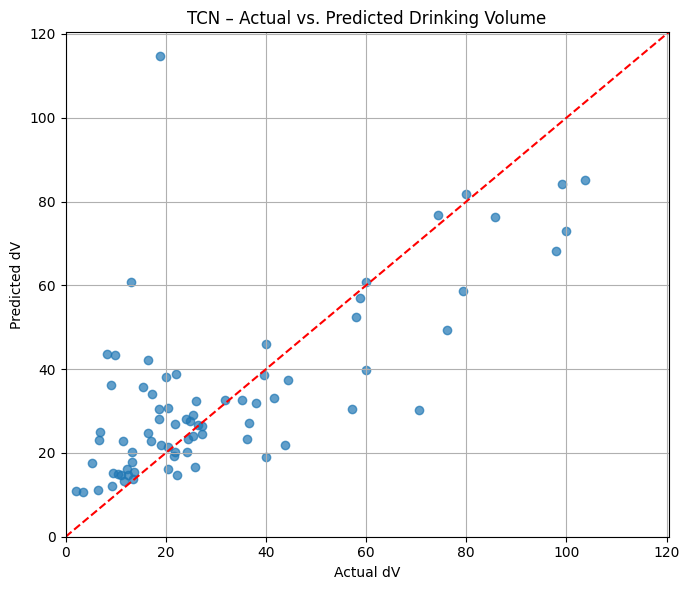


🧪 Training with optimizer: Adadelta


Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, None, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ tcn_4 (TCN)                     │ (None, 256)            │     5,230,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,230,593 (19.95 MB)

 Trainable params: 5,230,593 (19.95 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/500
123/123 ━━━━━━━━━━━━━━━━━━━━ 10s 44ms/step - loss: 30.6457 - val_loss: 21.0361
Epoch 2/500
123/123 ━━━━━━━━━━━━━━━━━━━━ 8s 65ms/step - loss: 19.1034 - val_loss: 16.0355
Epoch 3/500
123/123 ━━━━━━━━━━━━━━━━━━━━ 8s 67ms/step - loss: 15.6918 - val_loss: 18.3751
Epoch 4/500
123/123 ━━━━━━━━━━━━━━━━━━━━ 8s 68ms/step - loss: 16.7518 - val_loss: 19.3206
Epoch 5/500
123/123 ━━━━━━━━━━━━━━━━━━━━ 8s 69ms/step - loss: 15.4964 - val_loss: 15.5159
Epoch 6/500
123/123 ━━━━━━━━━━━━━━━━━━━━ 8s 67ms/step - loss: 13.9879 - val_loss: 14.0246
Epoch 7/500
123/123 ━━━━━━━━━━━━━━━━━━━━ 8s 67ms/step - loss: 14.3285 - val_loss: 14.0844
Epoch 8/500
123/123 ━━━━━━━━━━━━━━━━━━━━ 8s 67ms/step - loss: 11.6851 - val_loss: 15.8252
Epoch 9/500
123/123 ━━━━━━━━━━━━━━━━━━━━ 8s 68ms/step - loss: 12.7338 - val_loss: 15.6666
Epoch 10/500
123/123 ━━━━━━━━━━━━━━━━━━━━ 8s 68ms/step - loss: 11.9839 - val_loss: 16.3093
Epoch 11/500
123/123 ━━━━━━━━━━━━━━━━━━━━ 8s 67ms/step - loss: 10.5284 - val_loss: 15.4466
Epoch 1

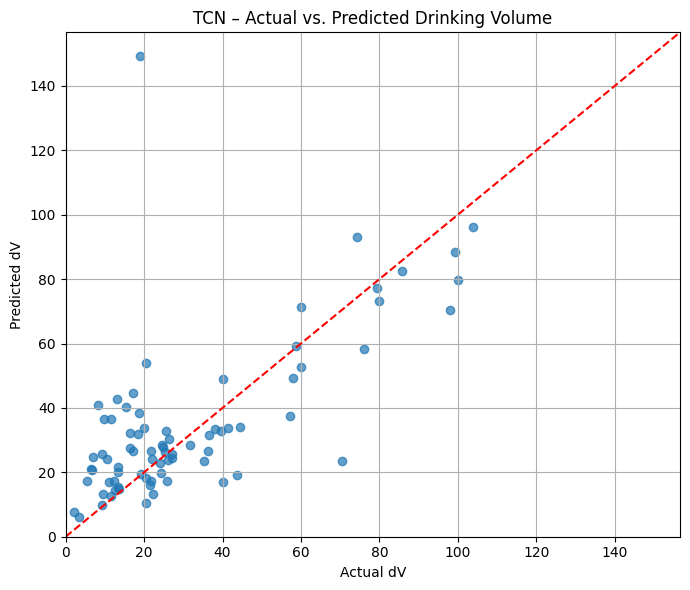


🧪 Training with optimizer: Adam


Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, None, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ tcn_5 (TCN)                     │ (None, 256)            │     5,230,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,230,593 (19.95 MB)

 Trainable params: 5,230,593 (19.95 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/500
123/123 ━━━━━━━━━━━━━━━━━━━━ 9s 40ms/step - loss: 23.7544 - val_loss: 17.8348
Epoch 2/500
123/123 ━━━━━━━━━━━━━━━━━━━━ 6s 45ms/step - loss: 17.0021 - val_loss: 19.0376
Epoch 3/500
123/123 ━━━━━━━━━━━━━━━━━━━━ 6s 48ms/step - loss: 18.3084 - val_loss: 15.8046
Epoch 4/500
123/123 ━━━━━━━━━━━━━━━━━━━━ 6s 47ms/step - loss: 15.8854 - val_loss: 15.8060
Epoch 5/500
123/123 ━━━━━━━━━━━━━━━━━━━━ 6s 49ms/step - loss: 15.2864 - val_loss: 16.0408
Epoch 6/500
123/123 ━━━━━━━━━━━━━━━━━━━━ 6s 50ms/step - loss: 13.6895 - val_loss: 16.1936
Epoch 7/500
123/123 ━━━━━━━━━━━━━━━━━━━━ 6s 48ms/step - loss: 12.2645 - val_loss: 14.6627
Epoch 8/500
123/123 ━━━━━━━━━━━━━━━━━━━━ 6s 49ms/step - loss: 12.7486 - val_loss: 16.8454
Epoch 9/500
123/123 ━━━━━━━━━━━━━━━━━━━━ 7s 53ms/step - loss: 11.3760 - val_loss: 15.8791
Epoch 10/500
123/123 ━━━━━━━━━━━━━━━━━━━━ 6s 50ms/step - loss: 10.8817 - val_loss: 15.2542
Epoch 11/500
123/123 ━━━━━━━━━━━━━━━━━━━━ 6s 51ms/step - loss: 10.1963 - val_loss: 19.9005
Epoch 12

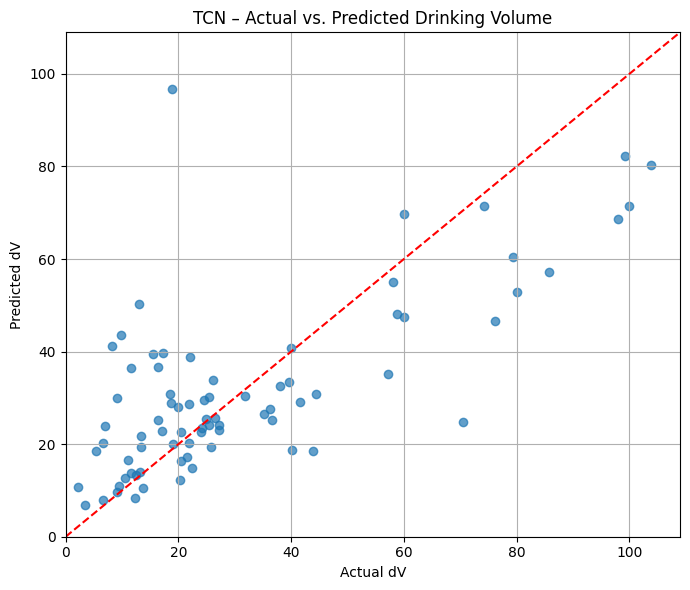


🧪 Training with optimizer: Adamax


Model: "functional_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)      │ (None, None, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ tcn_6 (TCN)                     │ (None, 256)            │     5,230,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,230,593 (19.95 MB)

 Trainable params: 5,230,593 (19.95 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/500
123/123 ━━━━━━━━━━━━━━━━━━━━ 9s 37ms/step - loss: 20.1232 - val_loss: 15.2749
Epoch 2/500
123/123 ━━━━━━━━━━━━━━━━━━━━ 6s 48ms/step - loss: 14.9941 - val_loss: 17.1343
Epoch 3/500
123/123 ━━━━━━━━━━━━━━━━━━━━ 6s 49ms/step - loss: 12.7505 - val_loss: 14.6742
Epoch 4/500
123/123 ━━━━━━━━━━━━━━━━━━━━ 6s 51ms/step - loss: 11.8849 - val_loss: 15.4174
Epoch 5/500
123/123 ━━━━━━━━━━━━━━━━━━━━ 6s 52ms/step - loss: 14.0215 - val_loss: 17.4957
Epoch 6/500
123/123 ━━━━━━━━━━━━━━━━━━━━ 6s 50ms/step - loss: 11.7406 - val_loss: 15.1074
Epoch 7/500
123/123 ━━━━━━━━━━━━━━━━━━━━ 6s 51ms/step - loss: 11.3968 - val_loss: 14.9145
Epoch 8/500
123/123 ━━━━━━━━━━━━━━━━━━━━ 6s 51ms/step - loss: 11.6539 - val_loss: 14.4063
Epoch 9/500
123/123 ━━━━━━━━━━━━━━━━━━━━ 6s 51ms/step - loss: 10.8726 - val_loss: 12.5469
Epoch 10/500
123/123 ━━━━━━━━━━━━━━━━━━━━ 6s 50ms/step - loss: 10.2933 - val_loss: 13.1844
Epoch 11/500
123/123 ━━━━━━━━━━━━━━━━━━━━ 6s 51ms/step - loss: 9.1226 - val_loss: 13.4952
Epoch 12/

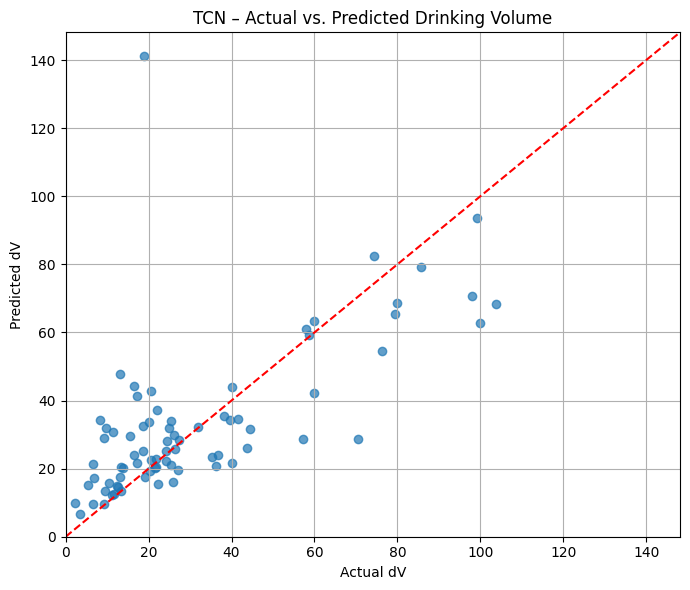


🧪 Training with optimizer: Nadam


Model: "functional_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_7 (InputLayer)      │ (None, None, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ tcn_7 (TCN)                     │ (None, 256)            │     5,230,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,230,593 (19.95 MB)

 Trainable params: 5,230,593 (19.95 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/500
123/123 ━━━━━━━━━━━━━━━━━━━━ 12s 43ms/step - loss: 22.4963 - val_loss: 21.8540
Epoch 2/500
123/123 ━━━━━━━━━━━━━━━━━━━━ 7s 53ms/step - loss: 18.5084 - val_loss: 17.9312
Epoch 3/500
123/123 ━━━━━━━━━━━━━━━━━━━━ 7s 53ms/step - loss: 17.2469 - val_loss: 18.5295
Epoch 4/500
123/123 ━━━━━━━━━━━━━━━━━━━━ 7s 55ms/step - loss: 14.6434 - val_loss: 16.0170
Epoch 5/500
123/123 ━━━━━━━━━━━━━━━━━━━━ 7s 53ms/step - loss: 13.8306 - val_loss: 16.4656
Epoch 6/500
123/123 ━━━━━━━━━━━━━━━━━━━━ 7s 54ms/step - loss: 13.4095 - val_loss: 15.7672
Epoch 7/500
123/123 ━━━━━━━━━━━━━━━━━━━━ 7s 54ms/step - loss: 11.7368 - val_loss: 15.3248
Epoch 8/500
123/123 ━━━━━━━━━━━━━━━━━━━━ 6s 53ms/step - loss: 12.9351 - val_loss: 17.7602
Epoch 9/500
123/123 ━━━━━━━━━━━━━━━━━━━━ 7s 55ms/step - loss: 13.3053 - val_loss: 15.2710
Epoch 10/500
123/123 ━━━━━━━━━━━━━━━━━━━━ 7s 53ms/step - loss: 9.8014 - val_loss: 14.2957
Epoch 11/500
123/123 ━━━━━━━━━━━━━━━━━━━━ 6s 52ms/step - loss: 13.3730 - val_loss: 14.5434
Epoch 12

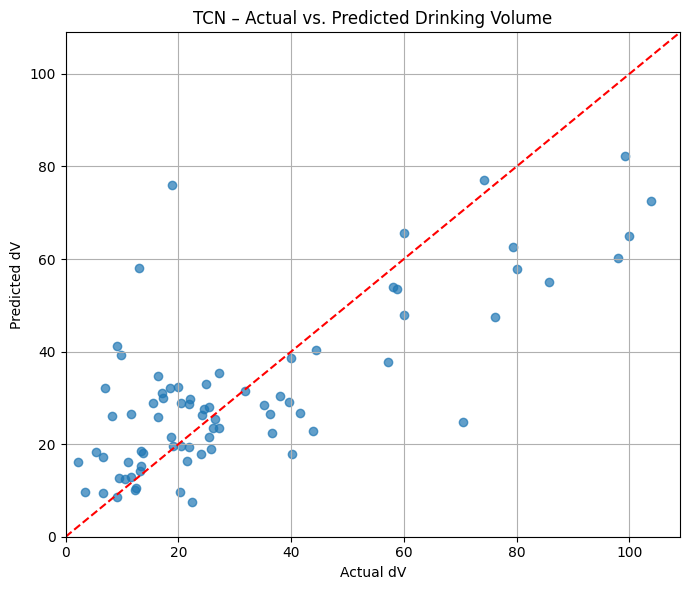

In [28]:
histories = {}

for name, opt in optimizers_to_test.items():
    history = build_and_train_model(opt, name)
    histories[name] = history


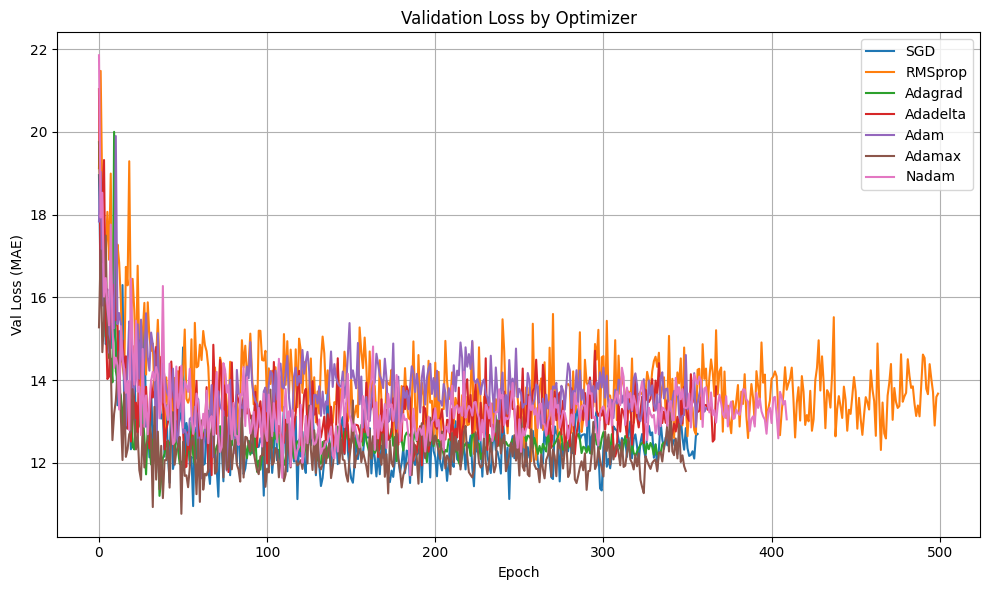

In [29]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

for name, history in histories.items():
    plt.plot(history.history['val_loss'], label=name)

plt.title('Validation Loss by Optimizer')
plt.xlabel('Epoch')
plt.ylabel('Val Loss (MAE)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
